In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load JSON data
with open('Single.json') as f:
    data = json.load(f)

results = []

# Process each trace
for trace in data['data']:
    trace_id = trace['traceID']
    spans = trace['spans']
    spans0 = spans[4]['duration']
        # Convert durations from microseconds to milliseconds
    results.append({
         'traceID': trace_id,
         'CS_Duration_In_ms': spans0 / 1000
    })
    
# Create a pandas DataFrame from the results
df_Single = pd.DataFrame(results)
df_Single.head()

,traceID,CS_Duration_In_ms
0,e4d59f519410aa9579e75754f3cc3704,630.426
1,94077179542a9fafa5a7429b20e36bb3,793.219
2,66c819752399458cb9e7adace221f697,978.395
3,0bee0d476a4296de83417c99fd5d1025,1150.892
4,cf41c6ff27f8607031269e776918cc57,1307.959


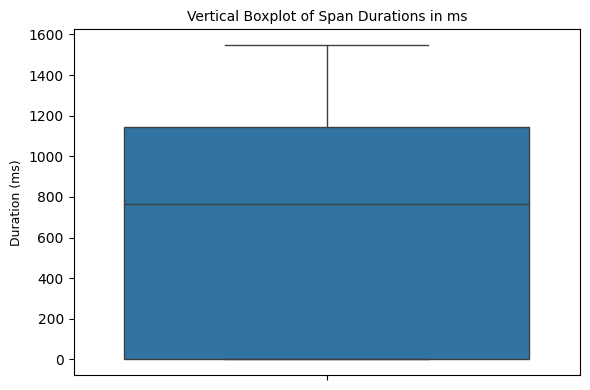

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Smaller vertical boxplot
plt.figure(figsize=(6, 4))  # smaller figure
sns.boxplot(y='CS_Duration_In_ms', data=df_Single)  # vertical by default
plt.title('Vertical Boxplot of Span Durations in ms', fontsize=10)
plt.ylabel('Duration (ms)', fontsize=9)
plt.tight_layout()
plt.show()


/tmp/ipykernel_68734/2449529434.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_Multiple['CS_Duration_In_ms'], labels=['Set 1'])


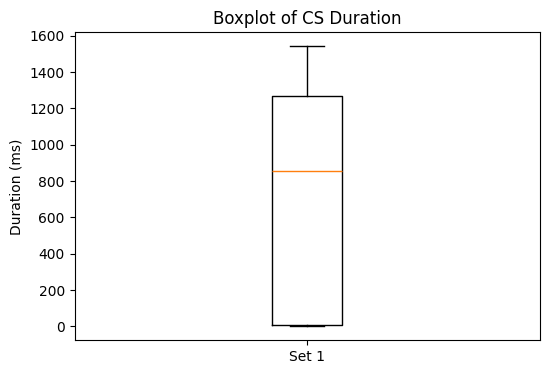

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load JSON data
with open('Multiple.json') as f:
    data = json.load(f)

results = []

# Process each trace
for trace in data['data']:
    trace_id = trace['traceID']
    spans = trace['spans']
    spans0 = spans[4]['duration']  # assuming there are at least 5 spans
    # Convert durations from microseconds to milliseconds
    results.append({
        'traceID': trace_id,
        'CS_Duration_In_ms': spans0 / 1000
    })

# Create a pandas DataFrame
df_Multiple = pd.DataFrame(results)

# Plot boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(df_Multiple['CS_Duration_In_ms'], labels=['Set 1'])
plt.ylabel('Duration (ms)')
plt.title('Boxplot of CS Duration')
plt.show()


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Smaller vertical boxplot
plt.figure(figsize=(6, 4))  # smaller figure
sns.boxplot(y='CS_Duration_In_ms', data=df)  # vertical by default
plt.title('Vertical Boxplot of Span Durations in ms', fontsize=10)
plt.ylabel('Duration (ms)', fontsize=9)
plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

<Figure size 600x400 with 0 Axes>

/tmp/ipykernel_68734/1663306704.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_Single['CS_Duration_In_ms'], df_Multiple['CS_Duration_In_ms']], labels=['Single', 'Multiple'])


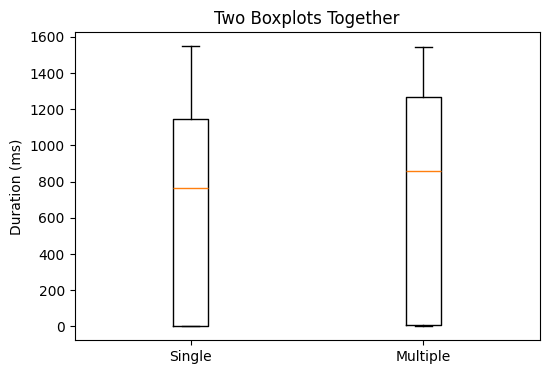

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot([df_Single['CS_Duration_In_ms'], df_Multiple['CS_Duration_In_ms']], labels=['Single', 'Multiple'])
plt.ylabel('Duration (ms)')
plt.title('Two Boxplots Together')
plt.show()


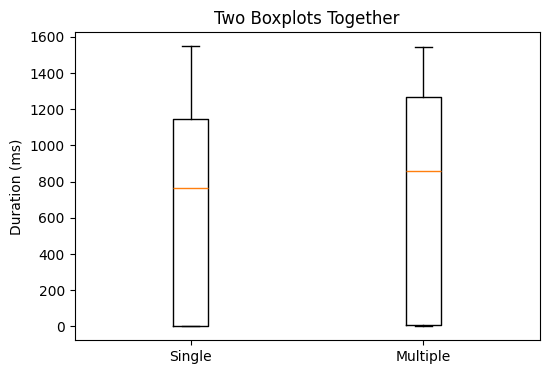

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(
    [df_Single['CS_Duration_In_ms'], df_Multiple['CS_Duration_In_ms']],
    tick_labels=['Single', 'Multiple']  # updated parameter name
)
plt.ylabel('Duration (ms)')
plt.title('Two Boxplots Together')
plt.show()


In [10]:
print("Single set stats:")
print(df_Single['CS_Duration_In_ms'].describe())

print("\nMultiple set stats:")
print(df_Multiple['CS_Duration_In_ms'].describe())


Single set stats:
count      30.000000
mean      665.990133
std       569.037861
min         0.225000
25%         2.363250
50%       763.727500
75%      1145.091500
max      1547.902000
Name: CS_Duration_In_ms, dtype: float64

Multiple set stats:
count      30.000000
mean      751.723167
std       579.461979
min         0.271000
25%         5.795500
50%       856.355000
75%      1267.299250
max      1541.981000
Name: CS_Duration_In_ms, dtype: float64


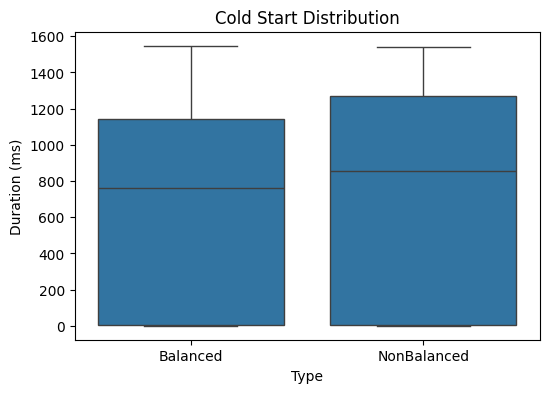

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

df_Single['Type'] = 'Balanced'
df_Multiple['Type'] = 'NonBalanced'
df_combined = pd.concat([df_Single, df_Multiple])

plt.figure(figsize=(6,4))
sns.boxplot(x='Type', y='CS_Duration_In_ms', data=df_combined)
plt.ylabel('Duration (ms)')
plt.title('Cold Start Distribution')
plt.savefig("ColdStart.png")
plt.show()
